# How to Run

**Delete this cell before final submission — it's for your reference only.**

### What this notebook does
Sanity-check the FaceForensics++ C23 dataset before you start the big preprocessing job. It lists folders, counts videos per class, peeks inside the `csv/` folder, and opens one sample video to confirm decoding works. Nothing is written to disk.

### Where to run it
**On your desktop (RTX 5080 machine), inside the same venv you set up in `00b_environment_setup.ipynb`.** You can also run it on Kaggle — it auto-detects which environment it's in.

### Setup steps (desktop)

1. **Download the dataset.** Two options:
   - **Option A (recommended): Kaggle API.** From PowerShell with your venv active:
     ```powershell
     pip install kaggle
     ```
     Then go to [kaggle.com/settings/account](https://www.kaggle.com/settings/account), scroll to *API*, click *Create New Token*. This downloads `kaggle.json`. Move it to `C:\Users\<you>\.kaggle\kaggle.json`. Now download:
     ```powershell
     kaggle datasets download xdxd003/ff-c23 -p D:\datasets\ff-c23 --unzip
     ```
     (Pick a drive with enough free space — the unzipped dataset is 17.92 GB.)
   - **Option B: Browser.** Go to [the dataset page](https://www.kaggle.com/datasets/xdxd003/ff-c23), download the zip manually, and extract to `D:\datasets\ff-c23\`.

2. **Update the `LOCAL_DATASET_ROOT` path in the config cell below** to point to wherever you extracted the dataset.

3. **Open this notebook in JupyterLab** (run `jupyter lab` from the venv) and run all cells.

### Expected runtime
2–3 minutes.

### What to look for
- All 6 manipulation folders + `original` + `csv` are present
- About 1000 videos per class
- The `csv/` folder contains official split files
- The sample video opens and the first frame displays correctly


# 00 — Dataset Exploration

Goal: understand the structure of the FaceForensics++ C23 dataset before we preprocess it.

## 1. Configuration

The notebook auto-detects whether you're running on Kaggle or a local machine. **If running locally, set `LOCAL_DATASET_ROOT` below to your extracted dataset path.**

In [9]:
import os
from pathlib import Path

# --- EDIT THIS LINE if you extracted the dataset somewhere else ---
LOCAL_DATASET_ROOT = Path(r'dataset\FaceForensics++_C23')

# Kaggle path is fixed by the platform.
KAGGLE_DATASET_ROOT = Path('/kaggle/input/ff-c23/FaceForensics++_C23')

# Detect environment automatically.
if KAGGLE_DATASET_ROOT.exists():
    DATASET_ROOT = KAGGLE_DATASET_ROOT
    print('Environment: Kaggle')
elif LOCAL_DATASET_ROOT.exists():
    DATASET_ROOT = LOCAL_DATASET_ROOT
    print('Environment: Local desktop')
else:
    raise FileNotFoundError(
        f'Dataset not found at either:\n'
        f'  Kaggle path: {KAGGLE_DATASET_ROOT}\n'
        f'  Local path:  {LOCAL_DATASET_ROOT}\n'
        f'Update LOCAL_DATASET_ROOT above to your extracted dataset folder.'
    )

print(f'Dataset root: {DATASET_ROOT}')

Environment: Local desktop
Dataset root: dataset\FaceForensics++_C23


## 2. List top-level folders

We expect to see: `Deepfakes`, `Face2Face`, `FaceShifter`, `FaceSwap`, `NeuralTextures`, `DeepFakeDetection`, `original`, `csv`.

In [10]:
top_level_entries = sorted([entry.name for entry in DATASET_ROOT.iterdir()])
print('Top-level entries:')
for entry_name in top_level_entries:
    print(f'  - {entry_name}')

Top-level entries:
  - DeepFakeDetection
  - Deepfakes
  - Face2Face
  - FaceShifter
  - FaceSwap
  - NeuralTextures
  - csv
  - original


## 3. Count videos per manipulation method

Each manipulation folder should contain ~1000 `.mp4` files.

In [11]:
# These are the class folders we care about for training.
# FaceShifter is held out for the cross-manipulation generalization test.
MANIPULATION_METHODS = [
    'original',
    'Deepfakes',
    'Face2Face',
    'FaceSwap',
    'NeuralTextures',
    'FaceShifter',  # held-out test only
]

def count_videos_in_folder(folder_path: Path) -> int:
    """Recursively count .mp4 files under a folder."""
    if not folder_path.exists():
        return 0
    return sum(1 for _ in folder_path.rglob('*.mp4'))

print(f'{"Method":<20} {"Video count":>12}')
print('-' * 34)
for method_name in MANIPULATION_METHODS:
    method_folder = DATASET_ROOT / method_name
    video_count = count_videos_in_folder(method_folder)
    print(f'{method_name:<20} {video_count:>12}')

Method                Video count
----------------------------------
original                     1000
Deepfakes                    1000
Face2Face                    1000
FaceSwap                     1000
NeuralTextures               1000
FaceShifter                  1000


## 4. Inspect the `csv/` folder

The original FaceForensics++ authors provide official train/val/test splits. If they're in this folder, we'll use them — it makes our results directly comparable to published papers.

In [12]:
csv_folder = DATASET_ROOT / 'csv'

if csv_folder.exists():
    csv_files = sorted(csv_folder.rglob('*'))
    print(f'Found {len(csv_files)} entries in csv/ folder:\n')
    for csv_path in csv_files:
        if csv_path.is_file():
            file_size_kb = csv_path.stat().st_size / 1024
            print(f'  {csv_path.relative_to(csv_folder)}  ({file_size_kb:.1f} KB)')
else:
    print('No csv/ folder found. We will create our own splits in the next notebook.')

Found 10 entries in csv/ folder:

  DeepFakeDetection.csv  (92.9 KB)
  Deepfakes.csv  (52.2 KB)
  Face2Face.csv  (52.2 KB)
  FaceShifter.csv  (54.2 KB)
  FaceSwap.csv  (51.2 KB)
  FF++_Metadata.csv  (413.2 KB)
  FF++_Metadata_Shuffled.csv  (413.2 KB)
  Mean_Data.csv  (0.4 KB)
  NeuralTextures.csv  (57.1 KB)
  original.csv  (47.3 KB)


## 5. Peek inside each csv/json split file

FF++ usually stores splits as JSON arrays of `[real_video_id, fake_source_video_id]` pairs. We print the type and first few entries of each file.

In [13]:
import json
import pandas as pd

if csv_folder.exists():
    for split_file in sorted(csv_folder.rglob('*')):
        if not split_file.is_file():
            continue
        print(f'\n--- {split_file.name} ---')
        try:
            if split_file.suffix == '.json':
                with open(split_file) as f:
                    split_data = json.load(f)
                print(f'Type: {type(split_data).__name__}, length: {len(split_data)}')
                print(f'First 3 entries: {split_data[:3]}')
            elif split_file.suffix == '.csv':
                df_preview = pd.read_csv(split_file, nrows=5)
                print(f'Shape (first 5 rows): {df_preview.shape}')
                print(df_preview)
        except Exception as e:
            print(f'Could not parse: {e}')


--- DeepFakeDetection.csv ---
Shape (first 5 rows): (5, 8)
   Unnamed: 0                                          File Path Label  \
0           0  DeepFakeDetection/01_02__meeting_serious__YVGY...  FAKE   
1           1  DeepFakeDetection/01_02__outside_talking_still...  FAKE   
2           2  DeepFakeDetection/01_02__talking_against_wall_...  FAKE   
3           3  DeepFakeDetection/01_02__walk_down_hall_angry_...  FAKE   
4           4  DeepFakeDetection/01_02__walking_down_indoor_h...  FAKE   

   Frame Count  Width  Height Codec  File Size(MB)  
0         1044   1920    1080  h264           6.43  
1          727   1920    1080  h264           5.05  
2          841   1920    1080  h264           3.31  
3          217   1920    1080  h264           1.11  
4          773   1920    1080  h264          12.05  

--- Deepfakes.csv ---
Shape (first 5 rows): (5, 8)
   Unnamed: 0              File Path Label  Frame Count  Width  Height Codec  \
0           0  Deepfakes/000_003.mp4  FAKE   

## 6. Sample one video and verify it opens

We pick one video from `original/` and open it with `decord` to confirm video decoding works.

In [14]:
# Install decord if not already available.
#import importlib.util
#if importlib.util.find_spec('decord') is None:
#    !pip install -q decord

Sample video: dataset\FaceForensics++_C23\original\000.mp4
Total frames: 396
Frame size: 640 x 480


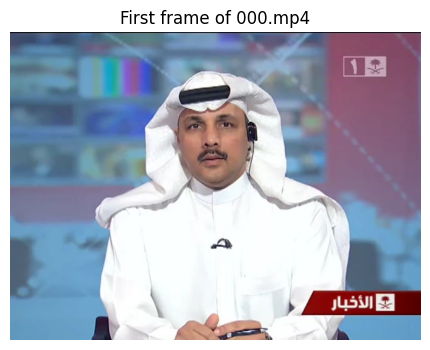

In [15]:
from decord import VideoReader, cpu
import matplotlib.pyplot as plt

# Grab the first available video from the 'original' class.
originals_folder = DATASET_ROOT / 'original'
sample_video_paths = list(originals_folder.rglob('*.mp4'))[:1]

assert len(sample_video_paths) > 0, 'No videos found in original/ folder.'
sample_video_path = sample_video_paths[0]
print(f'Sample video: {sample_video_path}')

video_reader = VideoReader(str(sample_video_path), ctx=cpu(0))
total_frames = len(video_reader)
frame_height, frame_width, _ = video_reader[0].asnumpy().shape
print(f'Total frames: {total_frames}')
print(f'Frame size: {frame_width} x {frame_height}')

# Show the first frame.
first_frame = video_reader[0].asnumpy()
plt.figure(figsize=(6, 4))
plt.imshow(first_frame)
plt.title(f'First frame of {sample_video_path.name}')
plt.axis('off')
plt.show()

## 7. Summary

If everything above worked:
- The dataset is correctly accessible.
- All expected manipulation folders are present with thousands of videos.
- Split files (if present) are now understood.
- Video decoding works.

We're ready to move to **`01_preprocessing.ipynb`**.